### General code

In [1]:
import sys
sys.path.insert(0, "/home/nfm/ViT-Prisma/src")

import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

import vit_prisma
from vit_prisma.utils.data_utils.imagenet.imagenet_dict import IMAGENET_DICT
from vit_prisma.utils import prisma_utils

import numpy as np
import torch
from fancy_einsum import einsum
from collections import defaultdict

import plotly.graph_objs as go
import plotly.express as px

import matplotlib.colors as mcolors

from PIL import Image
from torchvision import transforms
import matplotlib.pyplot as plt

from IPython.core.display import display, HTML


class ConvertTo3Channels:
    def __call__(self, img):
        if img.mode != 'RGB':
            return img.convert('RGB')
        return img

transform = transforms.Compose([
    ConvertTo3Channels(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

/home/nfm/prisma/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/nfm/prisma/lib/python3.12/site-packages/kaleido/_sync_server.py:11: UserWarning:




This means that static image generation (e.g. `fig.write_image()`) will not work.

Please upgrade Plotly to version 6.1.1 or greater, or downgrade Kaleido to version 0.2.1.


/tmp/ipykernel_115315/3027128810.py:25: DeprecationWarning:

Importing display from IPython.core.display is deprecated since IPython 7.14, please import from IPython.display



In [2]:
from vit_prisma.models.base_vit import HookedViT

# model_name = "hf_hub:natihash/vit_base_patch16_clip_224.laion2b_linear_probe_real"
# model_name = "vit_base_patch16_224"
# model_name = "vit_base_patch16_clip_224.laion2b_ft_in1k"
# model_name = "hf_hub:natihash/vit_base_patch16_clip_224.laion2b_fullft"
model_name = "open-clip:laion/CLIP-ViT-B-16-laion2B-s34B-b88K"
model = HookedViT.from_pretrained(model_name,
                                        center_writing_weights=True,
                                        center_unembed=True,
                                        fold_ln=True,
                                        refactor_factored_attn_matrices=True,
                                        device="cuda"
                                    )

model = model.to("cuda:0")
model.cfg.device = "cuda:0"
print("Model device config:", model.cfg.device)
print("Is CUDA available?:", torch.cuda.is_available())

2026-05-27 00:43:32 INFO:root: Model 'open-clip:laion/CLIP-ViT-B-16-laion2B-s34B-b88K' is supported and passes tests.
2026-05-27 00:43:32 INFO:root: model_id download_pretrained_from_hf: laion/CLIP-ViT-B-16-laion2B-s34B-b88K
2026-05-27 00:43:32 DEBUG:urllib3.connectionpool: Starting new HTTPS connection (1): huggingface.co:443


*****Loading model 'open-clip:laion/CLIP-ViT-B-16-laion2B-s34B-b88K' of type 'VISION'


2026-05-27 00:43:32 DEBUG:urllib3.connectionpool: https://huggingface.co:443 "HEAD /laion/CLIP-ViT-B-16-laion2B-s34B-b88K/resolve/main/open_clip_config.json HTTP/1.1" 307 0
2026-05-27 00:43:32 DEBUG:urllib3.connectionpool: https://huggingface.co:443 "HEAD /api/resolve-cache/models/laion/CLIP-ViT-B-16-laion2B-s34B-b88K/7288da5a0d6f0b51c4a2b27c624837a9236d0112/open_clip_config.json HTTP/1.1" 200 0
2026-05-27 00:43:33 INFO:root: model_id download_pretrained_from_hf: laion/CLIP-ViT-B-16-laion2B-s34B-b88K
2026-05-27 00:43:33 DEBUG:urllib3.connectionpool: https://huggingface.co:443 "HEAD /laion/CLIP-ViT-B-16-laion2B-s34B-b88K/resolve/main/open_clip_pytorch_model.bin HTTP/1.1" 302 0
2026-05-27 00:43:34 INFO:root: visual projection shape: torch.Size([768, 512])


LayerNorm folded.
Centered weights writing to residual stream


2026-05-27 00:43:42 INFO:root: Loaded pretrained model open-clip:laion/CLIP-ViT-B-16-laion2B-s34B-b88K into HookedTransformer


Model device config: cuda:0
Is CUDA available?: True


In [3]:
import json
LOCAL_JSON_PATH = "/home/nfm/ViT-Prisma/demos/imagenet_class_index.json"
with open(LOCAL_JSON_PATH, 'r') as f:
    imagenet_class_index = json.load(f)

wnid_to_name = {}
for idx, (wnid, class_name) in imagenet_class_index.items():
    safe_class_name = class_name.replace(" ", "_").replace("/", "_").replace(",", "")
    wnid_to_name[wnid] = safe_class_name

wnid_to_idx = {wnid: int(idx) for idx, (wnid, name) in imagenet_class_index.items()}
idx_to_name = {int(idx): name for idx, (wnid, name) in imagenet_class_index.items()}

idx_to_wnid = {int(idx): wnid for idx, (wnid, name) in imagenet_class_index.items()}
name_to_idx = {name: int(idx) for idx, (wnid, name) in imagenet_class_index.items()}

### Saving Head activations

In [ ]:
import os
import json
import torch
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from tqdm.auto import tqdm

# --- 1. CONFIGURATION ---
IMAGENET_VAL_DIR = '/home/nfm/data_prisma/imagenet_val/kaggle/input/imagenet-object-localization-challenge/ILSVRC/Data/CLS-LOC/val/'
# OUTPUT_DIR = '/home/nfm/ViT-Prisma/demos/head_acts_clipvit16_FullFT'
OUTPUT_DIR = '/home/nfm/ViT-Prisma/demos/head_acts_pure_clipvit16'
# OUTPUT_DIR = '/home/nfm/ViT-Prisma/demos/head_acts_pure_clipvit16_newdataset'
LOCAL_JSON_PATH = "/home/nfm/ViT-Prisma/demos/imagenet_class_index.json"

BATCH_SIZE = 50 # 50 images per class. 48GB GPU handles this easily!
LAYERS_TO_KEEP = 4 

os.makedirs(OUTPUT_DIR, exist_ok=True)

# --- 2. LOAD CLASS NAMES ---
with open(LOCAL_JSON_PATH, 'r') as f:
    imagenet_class_index = json.load(f)

wnid_to_name = {}
for idx, (wnid, class_name) in imagenet_class_index.items():
    safe_class_name = class_name.replace(" ", "_").replace("/", "_").replace(",", "")
    wnid_to_name[wnid] = safe_class_name

# --- 3. DATASET & DATALOADER ---
# ImageFolder automatically sorts by folder name, so 50 images per folder = perfect batches
dataset = ImageFolder(IMAGENET_VAL_DIR, transform=transform) 
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

# Calculate how many heads we are slicing (4 layers * 12 heads = 48 heads)
num_heads_to_keep = LAYERS_TO_KEEP * model.cfg.n_heads

print(f"Starting extraction. Saving {num_heads_to_keep}x50x{model.cfg.d_model} tensors...")

# --- 4. MAIN EXTRACTION LOOP ---
for batch_imgs, batch_labels in tqdm(dataloader, total=len(dataloader)):
    
    # Get the class info from the first image in the batch
    class_idx = batch_labels[0].item()
    folder_id = dataset.classes[class_idx]
    class_name = wnid_to_name.get(folder_id, "unknown_class")
    
    batch_imgs = batch_imgs.to(model.cfg.device)

    # --- 5. SAVE TO DISK ---
    filename = f"{folder_id}_{class_name}.pt"
    save_path = os.path.join(OUTPUT_DIR, filename)

    # if os.path.exists(save_path):
    #     continue
    
    with torch.no_grad():
        # Run forward pass and cache activations for all 50 images
        _, cache = model.run_with_cache(batch_imgs)
        
        # Extract the CLS token output for ALL heads
        # Shape: [144, 50, 768] (assuming 12 layers)
        all_head_residuals = cache.stack_head_results(layer=-1, pos_slice=0)

        scaled_head_residuals = cache.apply_ln_to_stack(
            all_head_residuals, layer=-1, pos_slice=0
        )
        
        # Slice to keep only the last 4 layers (last 48 indices on the 0th dimension)
        # Shape becomes: [48, 50, 768]
        last_4_layers_residual = scaled_head_residuals[-num_heads_to_keep:, :, :]
        

    
    # Move to CPU before saving to keep VRAM clear
    torch.save(last_4_layers_residual.cpu().clone(), save_path)
    
    # Clear cache and VRAM for the next class
    del cache
    del all_head_residuals
    del last_4_layers_residual
    del scaled_head_residuals
    torch.cuda.empty_cache()

print(f"Extraction complete! Saved to {OUTPUT_DIR}")

### Labelling CLIP ViT heads with direct text attribution

In [4]:
txt_pth = "/home/nfm/clip_text_span/text_descriptions/image_descriptions_general.txt"
with open(txt_pth, "r") as f:
    texts = [line.strip() for line in f.readlines()]

from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

IMAGENET_VAL_DIR = '/home/nfm/data_prisma/imagenet_val/kaggle/input/imagenet-object-localization-challenge/ILSVRC/Data/CLS-LOC/val/'
# OUTPUT_DIR = '/home/nfm/ViT-Prisma/demos/head_acts_clipvit16_FullFT'
LOCAL_JSON_PATH = "/home/nfm/ViT-Prisma/demos/imagenet_class_index.json"

BATCH_SIZE = 50 # 50 images per class. 48GB GPU handles this easily!

dataset = ImageFolder(IMAGENET_VAL_DIR) 
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

In [17]:
import os
import json
import torch
from torch import einsum

# TENSORS_DIR = '/home/nfm/ViT-Prisma/demos/head_acts_vitpatch16'
# TENSORS_DIR = '/home/nfm/ViT-Prisma/demos/head_acts_clip_linear_probe_real'
# ggg = "Linear Probe CLIP"
# TENSORS_DIR = '/home/nfm/ViT-Prisma/demos/head_acts_clipvit16_FullFT'
# ggg = "TIMM Full FT CLIP"
# TENSORS_DIR = '/home/nfm/ViT-Prisma/demos/head_acts_clipvit16_myfullft'
# ggg = "My Full FT CLIP"
TENSORS_DIR = '/home/nfm/ViT-Prisma/demos/head_acts_pure_clipvit16'
ggg = "Original Clip"

LOCAL_JSON_PATH = "/home/nfm/ViT-Prisma/demos/imagenet_class_index.json"

# Load the JSON to create a bulletproof WNID -> Integer Index mapping
with open(LOCAL_JSON_PATH, 'r') as f:
    imagenet_class_index = json.load(f)

# Create a reverse lookup: "n01440764" -> 0
wnid_to_idx = {wnid: int(idx) for idx, (wnid, name) in imagenet_class_index.items()}
idx_to_name = {int(idx): name for idx, (wnid, name) in imagenet_class_index.items()}

def residual_stack_to_logit_attn(centered_residual_stack, answer_residual_direction):
    # This subtracts the mean across the d_model dimension (dim=-1)
    # centered_residual_stack = residual_stack - residual_stack.mean(dim=-1, keepdim=True)
    
    raw_dla = torch.einsum(
        "h b d, c d -> h b c",  # h=heads, b=batch, d=d_model, c=classes
        centered_residual_stack,
        answer_residual_direction,
    )
    return raw_dla 

# --- 3. BUILD THE FINAL TENSOR ---
text_dict = torch.load("/home/nfm/ViT-Prisma/demos/text_dict.pt")
txt_pth = "/home/nfm/clip_text_span/text_descriptions/image_descriptions_general.txt"
with open(txt_pth, "r") as f:
    texts = [line.strip() for line in f.readlines()]
for_print = "With 3500 general text descriptions, model:" + ggg

# text_dict = torch.load("/home/nfm/ViT-Prisma/demos/text_dict_imagenet.pt")
# text_dict = text_dict.to("cuda")
# texts = [idx_to_name[i] for i in range(1000)]
# for_print = "With 1000 ImageNet class name descriptions, model:" + ggg

print(for_print)


proj_head = model.head.W_H
target_direction = text_dict @ proj_head.T
target_direction = target_direction.to(model.cfg.device)

start_inds = [0, 12, 24, 36]
start_inds = [45]
for xx in start_inds:
    # xx = 0
    head_idx = [xx+i for i in range(12)] # last 4 layers, all heads
    head_idx = [i for i in head_idx if i < 48]

    # head_idx = [5, 6, 10, 8, -2]
    # head_idx = [3, 4, 9, 2-12, 6-12]
    # head_idx = [i+36 for i in head_idx]
    head_idx = [i for i in range(36, 48)]

    final_tensor = torch.zeros(1000,len(head_idx), 50, len(texts)) # [ImageClass, Head, LogitClass]

    pths = [f for f in os.listdir(TENSORS_DIR) if f.endswith('.pt')]


    # print("Calculating DLA and aligning indices...")
    for pth in pths:
        # Extract the WNID from the filename (e.g., 'n01440764_tench.pt' -> 'n01440764')
        wnid = pth.split('_')[0]
        
        # Find its exact 0-999 integer index
        true_class_idx = wnid_to_idx[wnid]
        
        # Load and compute
        filepath = os.path.join(TENSORS_DIR, pth)
        per_head_residual = torch.load(filepath, weights_only=True).to(model.cfg.device) 
        
        per_head_attribution = residual_stack_to_logit_attn(per_head_residual[head_idx], target_direction)
        
        # Insert it into the EXACT right row based on its official ImageNet index
        final_tensor[true_class_idx] = per_head_attribution.cpu()

    final_tensor = final_tensor.detach().cpu()
    # print("Final tensor shape:", final_tensor.shape)
    # continue
    for shibu in range(len(head_idx)):
        print(f"Analyzing Layer {8+head_idx[shibu]//12} Head {head_idx[shibu]%12}...")    
        temp = torch.clone(final_tensor[:,shibu,:,:])
        gaga = 500
        values, flat_idx = temp.reshape(-1).topk(gaga, largest=True)

        # unravel flat indices to 3D coords
        A, B, C = temp.shape
        i = flat_idx // (B * C)
        j = (flat_idx % (B * C)) // C
        k = flat_idx % C
        indices = torch.stack([i, j, k], dim=1)


        top_names = []
        avg_vals = {}
        for i in range(gaga):
            top_names.append(texts[indices[i][2].item()])
            avg_vals[texts[indices[i][2].item()]] = avg_vals.get(texts[indices[i][2].item()], []) + [values[i].item()]

        #sort avg_vals by mean value
        # avg_vals = {k: sum(v)/len(v) for k, v in avg_vals.items()}
        # avg_vals = dict(sorted(avg_vals.items(), key=lambda item: item[1], reverse=True))


        from collections import Counter
        name_counts = Counter(top_names)
        # print(name_counts.most_common(20))
        # print(list(avg_vals.items())[:20])
        for name, count in name_counts.most_common(20):
            print(f"{name}: {count} : {sum(avg_vals[name])/len(avg_vals[name]):.3f}", end="||")
        print("\n" + "-"*50)

With 3500 general text descriptions, model:Original Clip
Analyzing Layer 11 Head 0...
Photo taken in Beijing, China: 29 : 1.385||Picture taken in Laos: 28 : 1.406||Picture taken in Bavaria, Germany: 24 : 1.422||Picture taken in Hungary: 21 : 1.329||Picture taken in China: 18 : 1.349||Photo taken in Bangkok, Thailand: 15 : 1.435||Photo taken in Seoul, South Korea: 15 : 1.403||A picture of Taiwan: 14 : 1.314||a picture of taiwan: 14 : 1.314||Image taken in Thailand: 13 : 1.431||Photo taken in the Italian coastal towns: 13 : 1.331||Image taken in the Thai beaches: 12 : 1.457||Image taken in South Korea: 12 : 1.372||Picture taken in Vietnam: 12 : 1.355||Image taken in the Thai temples: 11 : 1.391||Picture taken in South Korea: 11 : 1.349||Picture taken in Thailand: 10 : 1.403||Image snapped in the Thailand: 9 : 1.459||Picture taken in the Thai beaches: 9 : 1.399||A picture of South Korea: 8 : 1.332||
--------------------------------------------------
Analyzing Layer 11 Head 1...
Reflection

### Plots

In [ ]:
txt_pth = "/home/nfm/clip_text_span/text_descriptions/image_descriptions_general.txt"
with open(txt_pth, "r") as f:
    texts = [line.strip() for line in f.readlines()]

indices_dict = torch.load("/home/nfm/ViT-Prisma/demos/indices_forclip_dict.pt", weights_only=False)

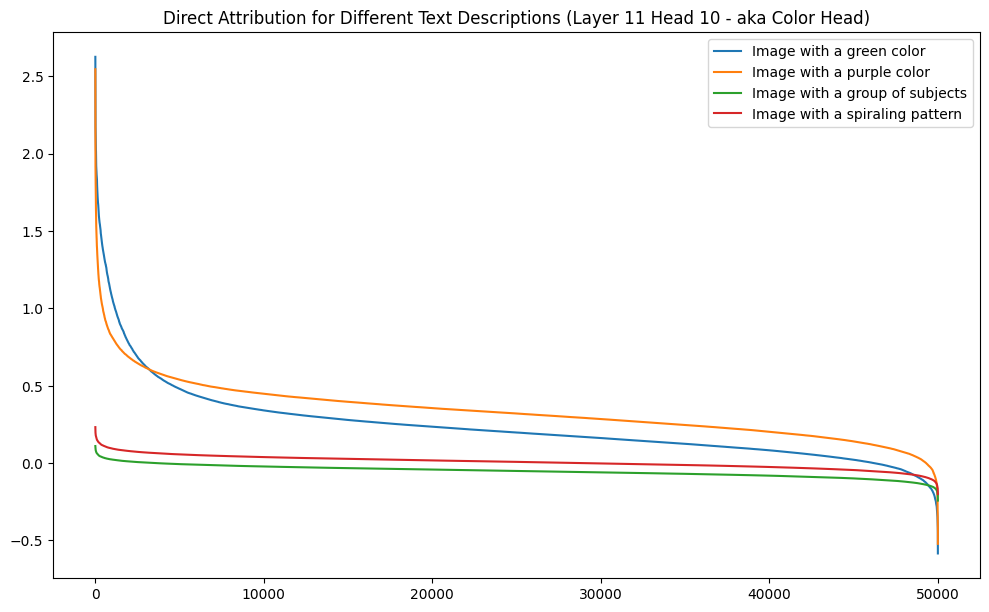

In [7]:
import matplotlib.pyplot as plt
import torch

plt.figure(figsize=(10, 6), dpi=100)  # higher dpi for display

for txt in [
    "Image with a green color",
    "Image with a purple color",
    "Image with a group of subjects",
    "Image with a spiraling pattern"
]:
    idx = texts.index(txt)
    temp = final_tensor[:, 1, :, idx].flatten()

    # sort temp
    temp = temp[torch.argsort(temp, descending=True)]

    plt.plot(temp.numpy(), label=txt)

plt.legend()
plt.tight_layout()
plt.title("Direct Attribution for Different Text Descriptions (Layer 11 Head 10 - aka Color Head)")

# Save high-resolution image
# plt.savefig("high_res_plot.png", dpi=300, bbox_inches="tight")

plt.show()

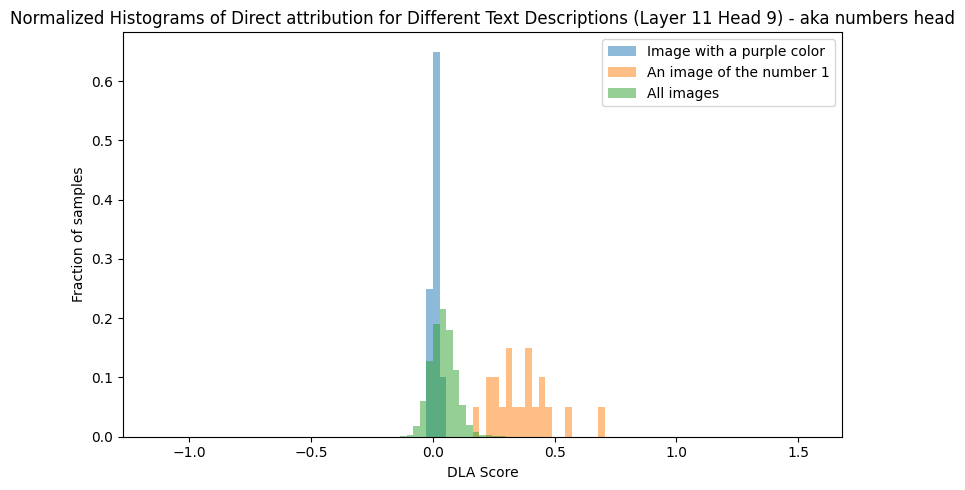

In [15]:
import numpy as np
import matplotlib.pyplot as plt

idx_head = 0
# build 1D numpy arrays for each case
txt1 = "Image with a purple color"
idx = texts.index(txt1); img_inds = indices_dict[idx][:20]
a1 = final_tensor[:, idx_head, :, idx].flatten()[img_inds].numpy()

# txt2 = "A photo with the letter A"
txt2 = "An image of the number 1"
idx = texts.index(txt2); img_inds = indices_dict[idx][:20]
a2 = final_tensor[:, idx_head, :, idx].flatten()[img_inds].numpy()

# all images
a3 = final_tensor[:, idx_head, :, :].flatten().numpy()

arrays = [a1, a2, a3]
labels = [txt1, txt2, "All images"]

# common bins
data_min = min(arr.min() for arr in arrays)
data_max = max(arr.max() for arr in arrays)
bins = np.linspace(data_min, data_max, 100)

plt.figure(figsize=(8,5))
for arr, label in zip(arrays, labels):
    weights = np.ones_like(arr) / arr.size            # normalizes counts by sample count
    plt.hist(arr, bins=bins, weights=weights, alpha=0.5, label=label)

plt.title("Normalized histograms (counts / n_samples)")
plt.xlabel("DLA Score")
plt.ylabel("Fraction of samples")
plt.title("Normalized Histograms of Direct attribution for Different Text Descriptions (Layer 11 Head 9) - aka numbers head")
plt.legend()
plt.tight_layout()
plt.show()

### Entropy and Predicting fate of heads

In [27]:
# !uv pip install zstandard

In [28]:
# save_dir = "/home/nfm/ViT-Prisma/mynotebooks/files"

# os.makedirs(save_dir, exist_ok=True)
# pth = os.path.join(save_dir, "CLIP_DTA_36_48.pt")
# torch.save(final_tensor, pth)
# final_tensor.shape

import torch
import zstandard as zstd

t = final_tensor.cpu().numpy().astype("float16")  # reduce first
cctx = zstd.ZstdCompressor(level=10)
compressed = cctx.compress(t.tobytes())

pth = os.path.join(save_dir, "CLIP_DTA_36_48.zst")
with open(pth, "wb") as f:
    f.write(compressed)

: 

In [21]:
import torch

num_bins = 50000

for i in range(12):
    temp = torch.clone(final_tensor[:, i, :, :]).flatten()

    # Compute histogram counts
    counts = torch.histc(
        temp,
        bins=num_bins,
        min=temp.min().item(),
        max=temp.max().item()
    )

    # Normalize to probability distribution
    probs = counts / counts.sum()

    # Remove zero probabilities to avoid log(0)
    probs_nonzero = probs[probs > 0]

    # Compute entropy (Shannon entropy, natural log)
    entropy = -torch.sum(probs_nonzero * torch.log(probs_nonzero))

    # If you want entropy in bits instead of nats:
    entropy_bits = entropy / torch.log(torch.tensor(2.0))

    print(f"Channel {i}:")
    print(f"  Counts shape: {counts.shape}")
    print(f"  Entropy (nats): {entropy.item():.6f}")
    print(f"  Entropy (bits): {entropy_bits.item():.6f}")

Channel 0:
  Counts shape: torch.Size([50000])
  Entropy (nats): 8.756939
  Entropy (bits): 12.633593
Channel 1:
  Counts shape: torch.Size([50000])
  Entropy (nats): 9.261744
  Entropy (bits): 13.361872
Channel 2:
  Counts shape: torch.Size([50000])
  Entropy (nats): 8.527819
  Entropy (bits): 12.303041
Channel 3:
  Counts shape: torch.Size([50000])
  Entropy (nats): 9.035011
  Entropy (bits): 13.034766
Channel 4:
  Counts shape: torch.Size([50000])
  Entropy (nats): 8.460434
  Entropy (bits): 12.205826
Channel 5:
  Counts shape: torch.Size([50000])
  Entropy (nats): 8.792178
  Entropy (bits): 12.684432
Channel 6:
  Counts shape: torch.Size([50000])
  Entropy (nats): 8.567451
  Entropy (bits): 12.360220
Channel 7:
  Counts shape: torch.Size([50000])
  Entropy (nats): 9.172358
  Entropy (bits): 13.232915
Channel 8:
  Counts shape: torch.Size([50000])
  Entropy (nats): 8.672577
  Entropy (bits): 12.511884
Channel 9:
  Counts shape: torch.Size([50000])
  Entropy (nats): 8.271406
  Entrop